# Pandas Practical Guide

In [52]:
import pandas as pd

In [53]:
# Importing Data
titanic = pd.read_csv('titanic.csv')

In [54]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [55]:
#To obtain list of columns
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [56]:
# Get the dimensions of DataFrame (rows and columns)
n_rows, n_cols = titanic.shape
print(n_rows,n_cols)

891 12


## Parts of a DataFrame
In the pandas library, there are two primary data structures:
* DataFrame-
  It is a 2-D labeled data structure. It consists of rows and columns and can hold different types of data.
* Series-
  A Series is a 1-dimensional labeled array.
Each column in a DataFrame is essentially a Series.

A DataFrame is a collection of multiple Series objects aligned along the same index (rows).

In [57]:
type(titanic)

pandas.core.frame.DataFrame

In [58]:
titanic['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [59]:
type(titanic['Name'])

pandas.core.series.Series

In [60]:
type(titanic[['Name','Age']])

pandas.core.frame.DataFrame

## Basics of selecting/renaming/reindexing Rows and Columns

In [61]:
# ename the columns of a DataFrame
titanic.rename(columns={'Cabin': 'Room'}, inplace=True)
titanic


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [62]:
#Drop columns from DataFrame
titanic_drop = titanic.drop(columns=['SibSp'])
titanic_drop.shape

(891, 11)

In [63]:
# By default, each row in a DataFrame is labelled using integers 0 to (n-1). To acess say the 5th:
titanic.loc[4]

PassengerId                           5
Survived                              0
Pclass                                3
Name           Allen, Mr. William Henry
Sex                                male
Age                                35.0
SibSp                                 0
Parch                                 0
Ticket                           373450
Fare                               8.05
Room                                NaN
Embarked                              S
Name: 4, dtype: object

In [64]:
# We can use Name to label the rows:
titanic_re = titanic.set_index('Name')
titanic_re

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
Name,,,,,,,,,,,
"Braund, Mr. Owen Harris",1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C
"Heikkinen, Miss. Laina",3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",4,1,1,female,35.0,1,0,113803,53.1000,C123,S
"Allen, Mr. William Henry",5,0,3,male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
"Montvila, Rev. Juozas",887,0,2,male,27.0,0,0,211536,13.0000,NaN,S
"Graham, Miss. Margaret Edith",888,1,1,female,19.0,0,0,112053,30.0000,B42,S
"Johnston, Miss. Catherine Helen ""Carrie""",889,0,3,female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [65]:
#Now since row index is Name to get the 5th row we can use iloc:
titanic_re.iloc[4]

PassengerId         5
Survived            0
Pclass              3
Sex              male
Age              35.0
SibSp               0
Parch               0
Ticket         373450
Fare             8.05
Room              NaN
Embarked            S
Name: Allen, Mr. William Henry, dtype: object

In [66]:
#To see first two rows
titanic.loc[0:1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [67]:
#to see first two columns
titanic.iloc[:, :4]

,PassengerId,Survived,Pclass,Name
0,1,0,3,"Braund, Mr. Owen Harris"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,3,1,3,"Heikkinen, Miss. Laina"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,5,0,3,"Allen, Mr. William Henry"
...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas"
887,888,1,1,"Graham, Miss. Margaret Edith"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie"""
889,890,1,1,"Behr, Mr. Karl Howell"


In [68]:
#Print first two columns
#Since the columns are also index using names like: Passengerid,Survived,Pclass etc we need to use iloc
titanic.iloc[:,0:4]
# : means all rows
# 0:4 means first 4 columns
# [2,3] will give columns with labels 2 and 3
titanic.iloc[:,[2,3]]

,Pclass,Name
0,3,"Braund, Mr. Owen Harris"
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,3,"Heikkinen, Miss. Laina"
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,3,"Allen, Mr. William Henry"
...,...,...
886,2,"Montvila, Rev. Juozas"
887,1,"Graham, Miss. Margaret Edith"
888,3,"Johnston, Miss. Catherine Helen ""Carrie"""
889,1,"Behr, Mr. Karl Howell"


In [69]:
#extract just 4th and 5th row as well as 1,2,3 columns
titanic.iloc[[3,4],[0,1,2]]

,PassengerId,Survived,Pclass
3,4,1,1
4,5,0,3


## Filtering

In [70]:
#extract rows with Age more than 30
titanic[titanic['Age']>30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [71]:
#Extract data with Age >30 and Fare less than 50
titanic[(titanic['Age']>30) & (titanic['Fare']<50)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
15,16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
18,19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [72]:
#Extract data with pclass 1 and 3
titanic[titanic['Pclass'].isin([1,3])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [73]:
# Drop index
titanic[(titanic['Age']==40)].reset_index(drop=True)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
0,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,NaN,C
1,41,0,3,"Ahlin, Mrs. Johan (Johanna Persdotter Larsson)",female,40.0,1,0,7546,9.4750,NaN,S
2,162,1,2,"Watt, Mrs. James (Elizabeth ""Bessie"" Inglis Mi...",female,40.0,0,0,C.A. 33595,15.7500,NaN,S
3,189,0,3,"Bourke, Mr. John",male,40.0,1,1,364849,15.5000,NaN,Q
4,210,1,1,"Blank, Mr. Henry",male,40.0,0,0,112277,31.0000,A31,C
5,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0000,B94,S
6,320,1,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",female,40.0,1,1,16966,134.5000,E34,C
7,347,1,2,"Smith, Miss. Marion Elsie",female,40.0,0,0,31418,13.0000,NaN,S
8,361,0,3,"Skoog, Mr. Wilhelm",male,40.0,1,4,347088,27.9000,NaN,S
9,562,0,3,"Sivic, Mr. Husein",male,40.0,0,0,349251,7.8958,NaN,S


## Sorting

In [74]:
titanic.sort_values(by='Fare',ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
...,...,...,...,...,...,...,...,...,...,...,...,...
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0000,NaN,S
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0000,NaN,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0000,B94,S
466,467,0,2,"Campbell, Mr. William",male,NaN,0,0,239853,0.0000,NaN,S


## Filtering with Strings

In [75]:
#lower 
titanic['Name'].str.lower()

0                                braund, mr. owen harris
1      cumings, mrs. john bradley (florence briggs th...
2                                 heikkinen, miss. laina
3           futrelle, mrs. jacques heath (lily may peel)
4                               allen, mr. william henry
                             ...                        
886                                montvila, rev. juozas
887                         graham, miss. margaret edith
888             johnston, miss. catherine helen "carrie"
889                                behr, mr. karl howell
890                                  dooley, mr. patrick
Name: Name, Length: 891, dtype: object

In [76]:
titanic['Name'] = titanic['Name'].str.lower()
#Check if any name contains reverence
titanic[titanic['Name'].str.contains("rev.")]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
149,150,0,2,"byles, rev. thomas roussel davids",male,42.00,0,0,244310,13.000,NaN,S
150,151,0,2,"bateman, rev. robert james",male,51.00,0,0,S.O.P. 1166,12.525,NaN,S
249,250,0,2,"carter, rev. ernest courtenay",male,54.00,1,0,244252,26.000,NaN,S
305,306,1,1,"allison, master. hudson trevor",male,0.92,1,2,113781,151.550,C22 C26,S
626,627,0,2,"kirkland, rev. charles leonard",male,57.00,0,0,219533,12.350,NaN,Q
848,849,0,2,"harper, rev. john",male,28.00,0,1,248727,33.000,NaN,S
886,887,0,2,"montvila, rev. juozas",male,27.00,0,0,211536,13.000,NaN,S


## Aggregations

In [77]:
# Number of distinct values in a column
titanic['Age'].nunique()

88

In [78]:
# describe (basic statistics for each column)
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [79]:
titanic['Age'].mean()

np.float64(29.69911764705882)

In [80]:
#value_counts (Count number of rows with each unique value of variable)
#(30 peaople with age 24, 27 with age 22, etc..)
titanic['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

## 

## 

## Plotting

<Axes: >

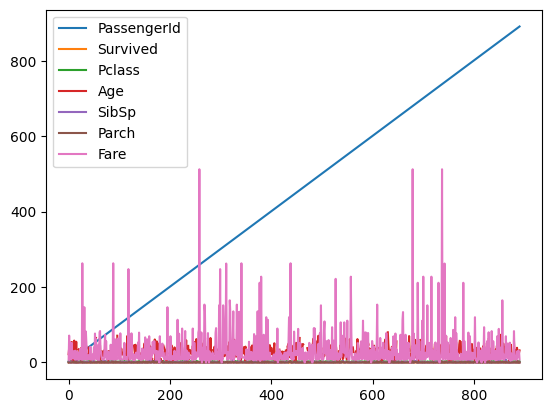

In [81]:
titanic.plot()

<Axes: >

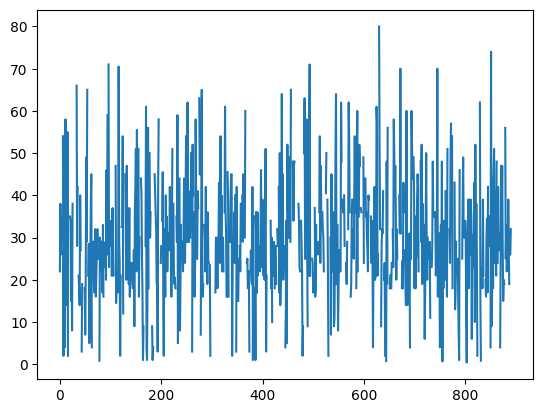

In [82]:
titanic['Age'].plot()

<Axes: xlabel='Age', ylabel='Survived'>

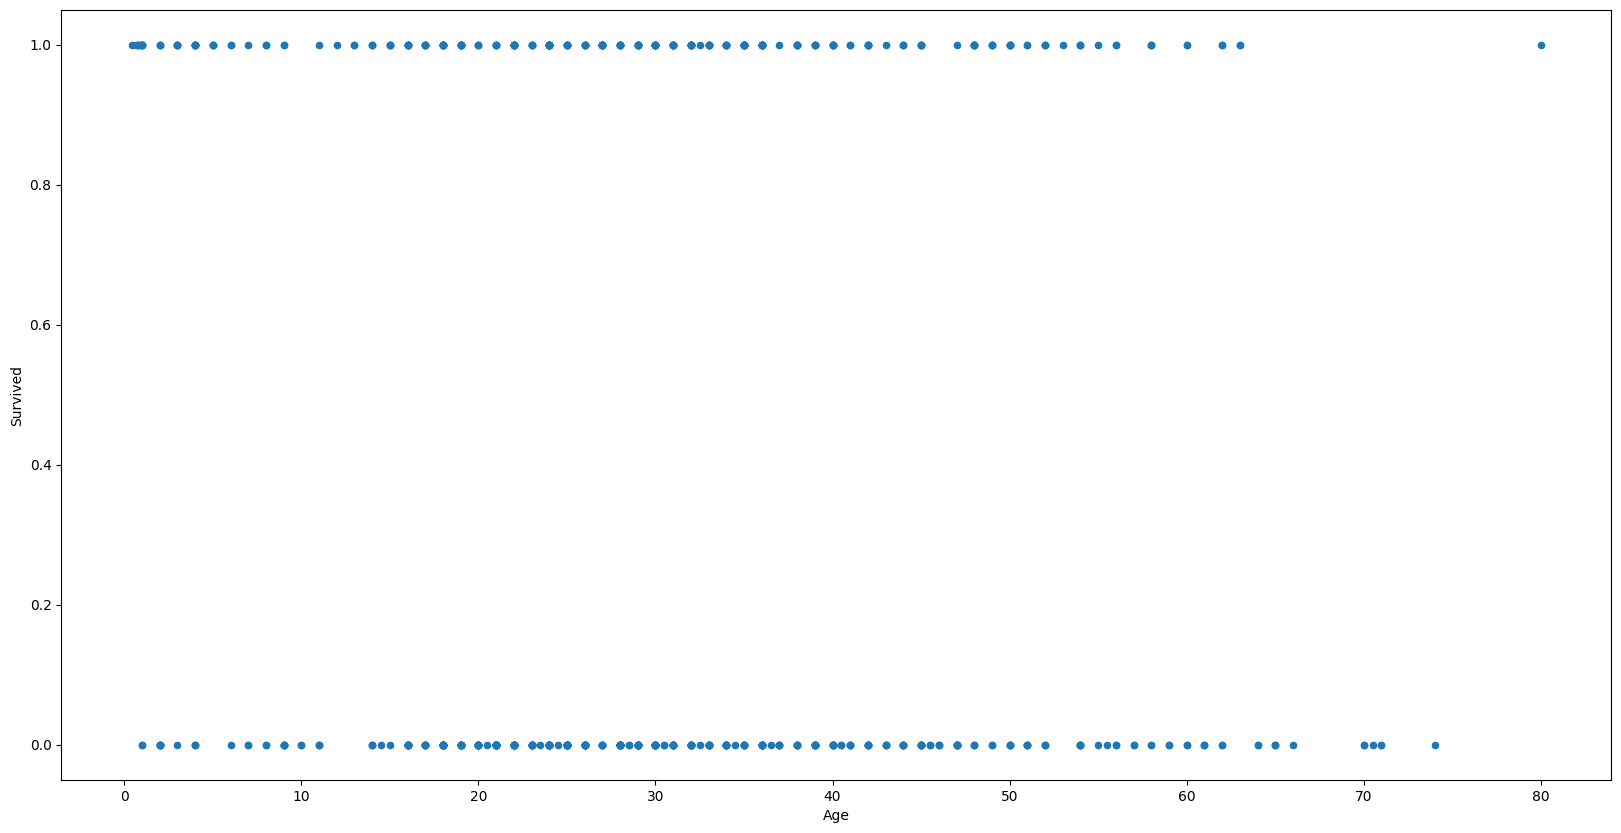

In [83]:
titanic[['Age','Survived']].plot(x='Age',y='Survived',kind='scatter',figsize=(20,10))

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

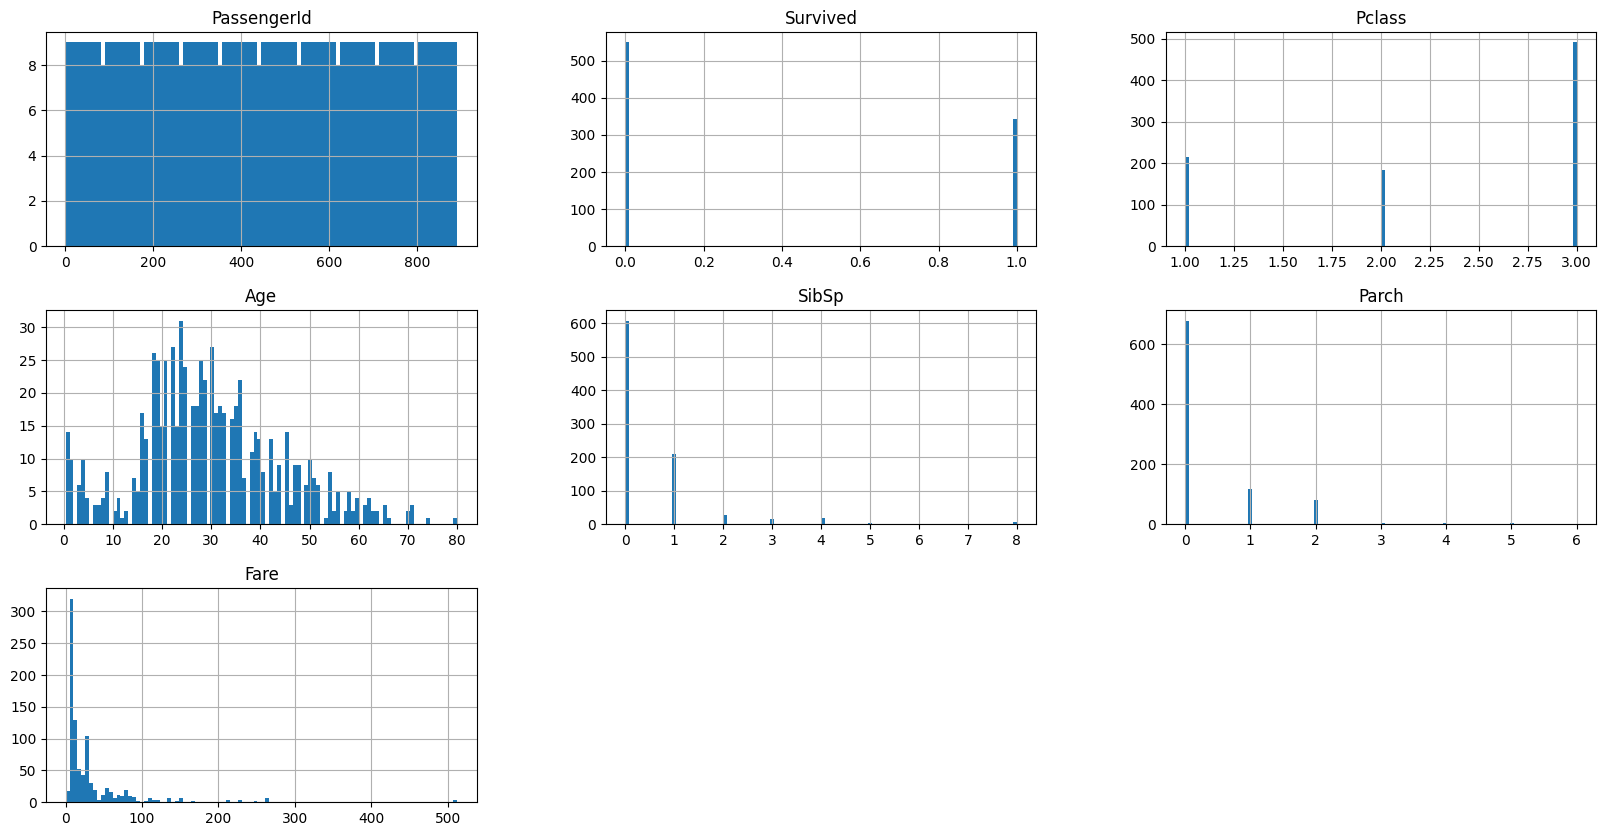

In [84]:
#histograms (Helps find outlier)
titanic.hist(figsize=(20,10),bins=100)

## Loading Space-Separated .data Files

In [85]:
Auto = pd.read_csv('Auto.data', sep=r"\s+") # sep as regex (whitespace or tab)
# or Auto = pd.read_csv('Auto.data', delim_whitespace=True) 
Auto.shape

(397, 9)

In [86]:
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

## Handeling Missing entries

In [87]:
# Remove rows with ? values
Auto = pd.read_csv('Auto.data',sep=r'\s+',na_values='?') # Replaces ? with NaN
Auto_re = Auto.dropna() # Drop rows with any column having NA or null data.
Auto_re.shape

(392, 9)

In [88]:
# Replace all NA/null data with value.
Auto = Auto.fillna('@')
Auto.iloc[32]

mpg                   25.0
cylinders                4
displacement          98.0
horsepower               @
weight              2046.0
acceleration          19.0
year                    71
origin                   1
name            ford pinto
Name: 32, dtype: object


## Using Query
query() allows Boolean expressions for filtering rows

In [89]:
titanic.query('Age > 20 and Fare > 50 and Name.str.contains("mr.")')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Room,Embarked
1,2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"mccarthy, mr. timothy j",male,54.0,0,0,17463,51.8625,E46,S
34,35,0,1,"meyer, mr. edgar joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
35,36,0,1,"holverson, mr. alexander oskar",male,42.0,1,0,113789,52.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
838,839,1,3,"chip, mr. chang",male,32.0,0,0,1601,56.4958,NaN,S
856,857,1,1,"wick, mrs. george dennick (mary hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
867,868,0,1,"roebling, mr. washington augustus ii",male,31.0,0,0,PC 17590,50.4958,A24,S
871,872,1,1,"beckwith, mrs. richard leonard (sallie monypeny)",female,47.0,1,1,11751,52.5542,D35,S


## Creating a dataframe
Add 2 new members to titanic

In [90]:
#Using dictionary (Most common way)
titanic = pd.read_csv('titanic.csv')
d = {'PassengerId':['892','893'], 'Survived':[0,1], 'Pclass':[3,1], 'Name':['Jack','Rose'], 'Sex':['male','female']}
df1 = pd.DataFrame(d)
df1.shape

(2, 5)

In [91]:
# Add more columns to df1
df1['Age'] = [22,19]
df1['SibSp'] = [0,1]
df1['Parch'] = [0,0]
df1['Ticket'] = ['A/5 21171', 'PC 17599']
df1['Fare'] = [7.25, 71.2833]
df1['Cabin']= [None, 'C85']
df1['Embarked']= ['S', 'C']
df1.shape


(2, 12)

In [92]:
titanic = pd.concat([titanic,df1])

In [93]:
titanic.reset_index()

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q
891,0,892,0,3,Jack,male,22.0,0,0,A/5 21171,7.2500,None,S


## Storing values as numpy


In [99]:
x = titanic['Age'].to_numpy() # x = titanic['Age'].values